# Visualización de Datos en Python — Notebook de ejemplo
### Maestría en Inteligencia Artificial · Módulo 1: Fundamentos de la Visualización

Este cuaderno es un **ejemplo de código real** para mostrar el uso de las principales librerías de graficación en Python:

- **pandas** para cargar y preparar los datos
- **Matplotlib** para control total del gráfico
- **Seaborn** para visualización estadística
- **Plotly Express** para gráficos interactivos

Todos los ejemplos usan **datos sintéticos** generados en el propio cuaderno, así que **se ejecuta sin descargar nada** (ideal para Google Colab o Jupyter).

> Sugerencia para clase: ejecuta las celdas una por una y comenta qué cambia al modificar un parámetro.

## 0 · Preparación del entorno

En Colab casi todo viene preinstalado. Si falta algo, descomenta la siguiente celda.

In [1]:
# En Google Colab / entorno nuevo, descomenta si hace falta:
# !pip install pandas matplotlib seaborn plotly -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Que las gráficas de Matplotlib se muestren dentro del cuaderno
%matplotlib inline

# Paleta de la materia (puedes reutilizarla en todas tus gráficas)
VINO     = "#4D1434"
MAGENTA  = "#903163"
BERRY    = "#B2324B"
GRISAZUL = "#969FA7"
AZUL     = "#40619D"
PALETA   = [VINO, MAGENTA, BERRY, AZUL, GRISAZUL]

sns.set_theme(style="whitegrid")          # estilo base agradable de Seaborn
plt.rcParams["figure.figsize"] = (7, 4.5) # tamaño por defecto
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 1 · pandas: cargar y preparar los datos

Todo flujo de visualización empieza con los datos en un **DataFrame**. Aquí los generamos sintéticamente, pero en la práctica los cargarías así:

```python
df = pd.read_csv("ventas.csv")        # desde un CSV
df = pd.read_excel("ventas.xlsx")     # desde Excel
```

In [3]:
rng = np.random.default_rng(42)

# Dataset 1: ventas mensuales (para barras y líneas)
ventas = pd.DataFrame({
    "mes":   ["Ene", "Feb", "Mar", "Abr", "May", "Jun"],
    "monto": [18, 27, 23, 34, 30, 41],          # miles de MXN
    "meta":  [20, 25, 28, 30, 33, 36],
})

# Dataset 2: tiempos de respuesta por región (para Seaborn)
regiones = pd.DataFrame({
    "region": np.repeat(["Norte", "Centro", "Sur", "Bajío"], 120),
    "tiempo": np.concatenate([
        rng.normal(48,  7, 120),
        rng.normal(52, 12, 120),
        rng.normal(50,  5, 120),
        rng.normal(55, 15, 120),
    ]),
})

# Dataset 3: empleados (para Plotly: dispersión/burbujas)
n = 90
empleados = pd.DataFrame({
    "antiguedad": rng.uniform(0, 10, n),
    "equipo":     rng.choice(["Ventas", "Datos", "Soporte"], n),
    "tamano":     rng.uniform(8, 28, n),
})
empleados["satisfaccion"] = 40 + empleados["antiguedad"]*4 + rng.normal(0, 8, n)

ventas.head()

,mes,monto,meta
0,Ene,18,20
1,Feb,27,25
2,Mar,23,28
3,Abr,34,30
4,May,30,33


In [4]:
# Operaciones típicas de pandas antes de graficar
print("Venta total del semestre:", ventas["monto"].sum(), "mil MXN")
print("Tiempo promedio por región:")
print(regiones.groupby("region")["tiempo"].mean().round(1))

Venta total del semestre: 173 mil MXN
Tiempo promedio por región:
region
Bajío     54.8
Centro    51.6
Norte     47.6
Sur       50.3
Name: tiempo, dtype: float64


## 2 · Matplotlib: control total del gráfico

Matplotlib es la base del ecosistema. Es verboso, pero te da **control absoluto** de cada elemento.

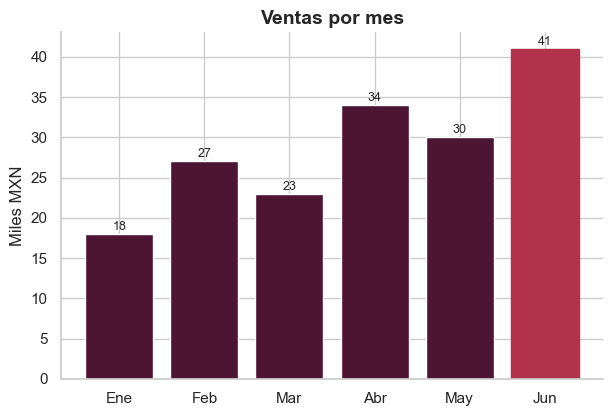

In [5]:
fig, ax = plt.subplots()

barras = ax.bar(ventas["mes"], ventas["monto"], color=VINO, edgecolor="white")
barras[ventas["monto"].idxmax()].set_color(BERRY)   # resaltar el mes máximo

ax.set_title("Ventas por mes", fontsize=14, weight="bold")
ax.set_ylabel("Miles MXN")
ax.spines[["top", "right"]].set_visible(False)

# etiquetar cada barra con su valor
for x, y in zip(ventas["mes"], ventas["monto"]):
    ax.text(x, y + 0.5, str(y), ha="center", fontsize=9)

plt.show()

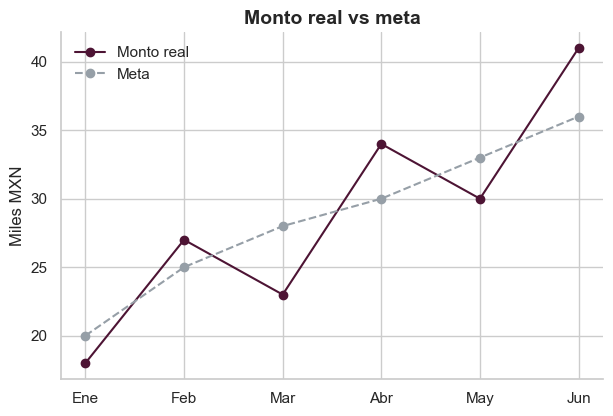

In [6]:
# Gráfico de líneas: comparar monto vs meta a lo largo del tiempo
fig, ax = plt.subplots()
ax.plot(ventas["mes"], ventas["monto"], marker="o", color=VINO,  label="Monto real")
ax.plot(ventas["mes"], ventas["meta"],  marker="o", color=GRISAZUL, ls="--", label="Meta")
ax.set_title("Monto real vs meta", fontsize=14, weight="bold")
ax.set_ylabel("Miles MXN")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

## 3 · Seaborn: visualización estadística sobre pandas

Seaborn trabaja directo con DataFrames y produce gráficos **estadísticos** con muy buena estética por defecto.

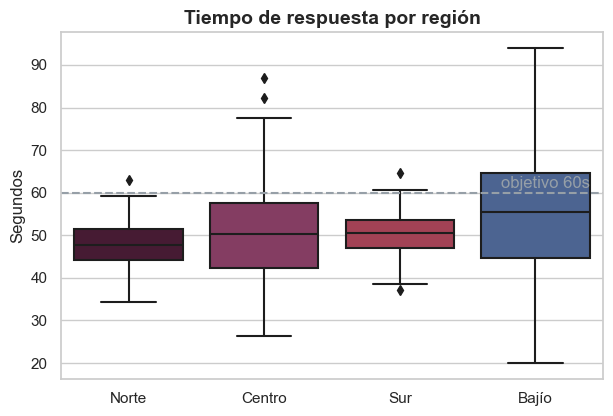

In [7]:
# Boxplot: distribución del tiempo de respuesta por región
fig, ax = plt.subplots()
# La firma de sns.boxplot cambió entre versiones:
#   seaborn >= 0.13 pide hue= y acepta legend=False
#   seaborn <  0.13 no conoce legend= (acepta palette sin hue)
try:
    sns.boxplot(data=regiones, x="region", y="tiempo",
                hue="region", palette=PALETA[:4], legend=False, ax=ax)
except TypeError:
    sns.boxplot(data=regiones, x="region", y="tiempo",
                palette=PALETA[:4], ax=ax)
ax.axhline(60, color=GRISAZUL, ls="--")          # objetivo de servicio: 60 s
ax.text(3.4, 61, "objetivo 60s", color=GRISAZUL, ha="right")
ax.set_title("Tiempo de respuesta por región", fontsize=14, weight="bold")
ax.set_ylabel("Segundos"); ax.set_xlabel("")
plt.show()

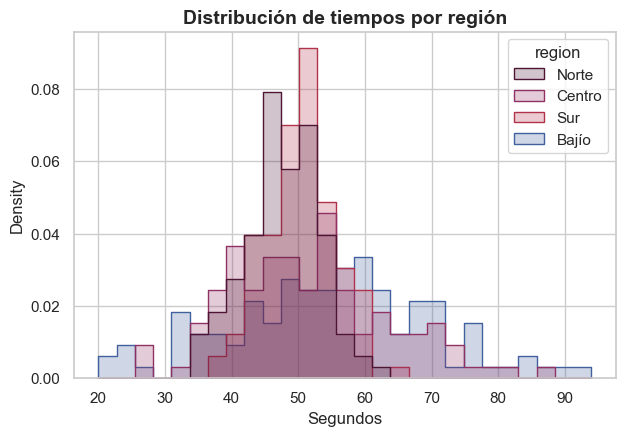

In [8]:
# Histograma + densidad: forma de la distribución
fig, ax = plt.subplots()
sns.histplot(data=regiones, x="tiempo", hue="region",
             palette=PALETA[:4], element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Distribución de tiempos por región", fontsize=14, weight="bold")
ax.set_xlabel("Segundos")
plt.show()

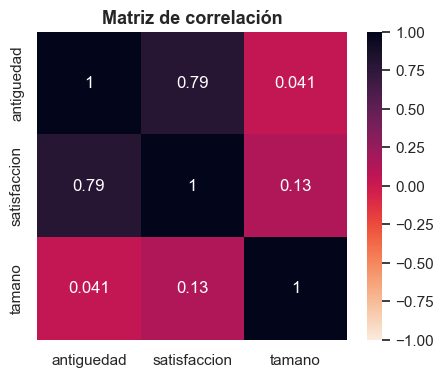

In [9]:
# Mapa de calor: correlación entre variables numéricas
corr = empleados[["antiguedad", "satisfaccion", "tamano"]].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="rocket_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación", fontsize=13, weight="bold")
plt.show()

## 4 · Plotly Express: gráficos interactivos

Con **pocas líneas** obtienes gráficos con *zoom*, *hover* y filtros. En Jupyter/Colab son interactivos (prueba pasar el cursor sobre los puntos).

In [10]:
fig = px.scatter(
    empleados, x="antiguedad", y="satisfaccion",
    color="equipo", size="tamano", size_max=22,
    color_discrete_map={"Ventas": VINO, "Datos": BERRY, "Soporte": AZUL},
    labels={"antiguedad": "Antigüedad (años)", "satisfaccion": "Satisfacción"},
    title="Satisfacción vs antigüedad (interactivo)",
)
fig.update_layout(template="plotly_white", legend_title_text="")
fig.show()

In [11]:
# Línea interactiva: monto vs meta
fig = px.line(
    ventas.melt(id_vars="mes", value_vars=["monto", "meta"],
                var_name="serie", value_name="valor"),
    x="mes", y="valor", color="serie", markers=True,
    color_discrete_map={"monto": VINO, "meta": GRISAZUL},
    title="Monto real vs meta (interactivo)",
)
fig.update_layout(template="plotly_white", legend_title_text="")
fig.show()

## 5 · Puente al Módulo 2: mapas

Plotly también hace **mapas coroplÉticos** sin instalar nada extra. En el Módulo 2 profundizamos con Folium y GeoPandas para datos de México.

In [12]:
# Ejemplo con datos integrados de Plotly (esperanza de vida por país, 2007)
gap = px.data.gapminder().query("year == 2007")
fig = px.choropleth(
    gap, locations="iso_alpha", color="lifeExp",
    hover_name="country", color_continuous_scale="Magma",
    title="Esperanza de vida por país (2007)",
)
fig.update_layout(margin=dict(l=0, r=0, t=50, b=0))
fig.show()

## 6 · La IA como copiloto (y por qué siempre verificas)

Puedes pedirle a un asistente de IA (Claude, Copilot) que escriba o corrija el código de una gráfica. Acelera el primer borrador, pero **tú decides y verificas**.

**Ejemplos de prompts útiles:**

- *"Convierte este gráfico de barras de Matplotlib a Plotly Express, manteniendo el color vino."*
- *"Mi boxplot lanza un FutureWarning de Seaborn; corrígelo usando hue."*
- *"Sugiere el mejor tipo de gráfico para comparar el tiempo de respuesta entre 4 regiones y explica por qué."*

**Antes de usar lo que genere la IA, revisa:**

1. ¿Usa la **columna y los datos correctos**?
2. ¿El **tipo de gráfico** es el adecuado para el mensaje?
3. ¿Se **ejecuta sin errores** y el resultado **dice la verdad** (sin distorsionar)?

> La IA puede *mostrar* un gráfico convincente sin *explicar* si es honesto. Esa verificación es trabajo tuyo.

### Ejercicio sugerido

Toma el DataFrame `empleados` y construye, **en las tres librerías**, un gráfico que responda:
*¿la satisfacción crece con la antigüedad?* Luego, en 2–3 líneas, justifica cuál comunica mejor el mensaje y por qué.

In [13]:
# Tu espacio para el ejercicio
